# FilingLens AI · Exploratory Data Analysis

**Deliverable 1** · Anyone AI Final Project · Team 3

---

## Goal

Understand the dataset before building anything on top of it.

The system we are building answers questions about NASDAQ companies by reading their
annual filings. Before writing a single line of the pipeline, we need to know what we
are working against: how many documents, how long, whether the text can be extracted
at all, and whether they share a structure we can exploit.

**This notebook does not clean or transform anything.** Cleaning belongs to deliverable 2.
Here we measure and report, so that whoever processes these documents knows exactly
what to expect.

## Questions this notebook answers

1. How large is the dataset and how is it organised
2. How long is a 10-K in pages and in characters
3. Can the text be extracted, or are some documents scanned images
4. Do the documents share the numbered Item structure we want to chunk by
5. How many chunks will the final corpus produce
6. Is the filename metadata trustworthy
7. Which recognisable companies cover 2019 to 2021

## How to reproduce

```bash
python eda/explore_s3.py        # lists the bucket, saves the bucket inventory
python eda/download_sample.py   # downloads the working sample
python eda/characterize.py      # measures the documents
```

Those three scripts produce the data this notebook reads. **No figure in this notebook is
typed by hand:** every number comes from a file the scripts wrote to `data/`.

## 1. Setup

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", None)

# Consistent look for every chart
PALETTE = {"primary": "#0f9b86", "accent": "#2540D9", "warn": "#d15a44", "muted": "#b4bac0"}
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
    "font.size": 10,
})

ROOT = Path.cwd().parent if Path.cwd().name == "eda" else Path.cwd()
DATA = ROOT / "data"
print("Project root:", ROOT)

Project root: /home/likecomtic/filinglens


In [2]:
inv = pd.read_csv(DATA / "raw" / "inventario.csv")
chars = pd.read_csv(DATA / "eda" / "caracterizacion.csv")

with open(DATA / "eda" / "caracterizacion.json", encoding="utf-8") as f:
    detail = json.load(f)

# characterize.py writes Spanish column names; the notebook works in English
chars = chars.rename(columns={
    "archivo": "file", "anio": "fiscal_year", "peso_mb": "size_mb",
    "paginas": "pages", "caracteres": "chars", "palabras": "words",
    "chars_por_pagina": "chars_per_page", "paginas_sin_texto": "blank_pages",
    "pct_sin_texto": "pct_blank", "tablas_en_40p": "tables_40p",
    "items_encontrados": "items_found", "fragmentos_est": "chunks_est_script",
})

df = chars.merge(
    inv[["ticker", "fiscal_year", "company", "s3_key"]],
    on=["ticker", "fiscal_year"], how="left", validate="one_to_one",
)
assert df["company"].notna().all(), "Some documents have no row in the inventory"

print(f"{len(df)} documents in the working sample")
df[["file", "ticker", "fiscal_year", "pages", "chars", "size_mb"]]

14 documents in the working sample


,file,ticker,fiscal_year,pages,chars,size_mb
0,AAPL_2019,AAPL,2019,101,357143,5.25
1,AAPL_2020,AAPL,2020,105,375680,0.86
2,AAPL_2021,AAPL,2021,82,296267,0.75
3,INTC_2019,INTC,2019,132,436399,6.22
4,INTC_2020,INTC,2020,132,470185,4.37
5,INTC_2021,INTC,2021,132,486208,9.38
6,MSFT_2019,MSFT,2019,94,290539,1.32
7,MSFT_2020,MSFT,2020,92,288722,0.82
8,MSFT_2021,MSFT,2021,94,293600,1.56
9,NVDA_2019,NVDA,2019,155,532162,23.94


## 2. The bucket

`explore_s3.py` lists the whole bucket without downloading anything. It parses every path
against the naming convention and writes two files:

- `data/eda/bucket_inventory.csv`: one row per file that follows the convention
- `data/eda/bucket_unparsed.csv`: everything that does not

In [3]:
bucket = pd.read_csv(DATA / "eda" / "bucket_inventory.csv")
unparsed = pd.read_csv(DATA / "eda" / "bucket_unparsed.csv")

is_pdf = unparsed["s3_key"].str.lower().str.endswith(".pdf")
odd_pdfs = unparsed[is_pdf]
all_pdf_keys = pd.concat([bucket["s3_key"], odd_pdfs["s3_key"]])
companies = all_pdf_keys.str.split("/").str[1].nunique()
total_mb = bucket["size_mb"].sum() + unparsed["size_mb"].sum()
n_files = len(bucket) + len(unparsed)

summary = pd.Series({
    "Files": f"{n_files:,}",
    "PDFs": f"{len(all_pdf_keys):,}",
    "Other files": ", ".join(unparsed.loc[~is_pdf, "s3_key"].str.split("/").str[-1]) or "none",
    "Total size": f"{total_mb / 1024:.1f} GB",
    "Average size": f"{total_mb / n_files:.1f} MB per file",
    "Companies": f"{companies:,}",
    "Follow the naming convention": f"{len(bucket):,}",
    "   of which with a hash suffix": f"{bucket['has_hash_suffix'].sum():,}",
    "PDFs outside the convention": f"{len(odd_pdfs):,}",
    "Fiscal years": f"{bucket['fiscal_year'].min()} to {bucket['fiscal_year'].max()}",
}, name="value")
summary.to_frame()

,value
Files,"9,856"
PDFs,"9,855"
Other files,.DS_Store
Total size,29.8 GB
Average size,3.1 MB per file
Companies,"2,428"
Follow the naming convention,"9,852"
of which with a hash suffix,45
PDFs outside the convention,3
Fiscal years,2003 to 2022


### Finding 1 · Metadata lives in the filename

```
nasdaq_annual_reports/apple-inc/NASDAQ_AAPL_2019.pdf
                      └───┬───┘ └─┬──┘ └┬─┘ └┬─┘
                       company exch. tick year
```

Anyone AI applied a naming convention to the bucket. **Company, exchange, ticker and fiscal
year can be parsed from the path, without opening a single PDF.**

The convention holds for 9,852 of 9,855 PDFs. 45 of them carry a 32-character hash after the
year (`NASDAQ_ICUI_2016_be05….pdf`), which is a variant of the same rule and parses the same
way. The only real exception is Fox Corporation:

In [4]:
odd_pdfs[["s3_key"]]

,s3_key
1,nasdaq_annual_reports/fox-corporation/fox-corporation_2019.pdf
2,nasdaq_annual_reports/fox-corporation/fox-corporation_2020.pdf
3,nasdaq_annual_reports/fox-corporation/fox-corporation_2021.pdf


Fox is not a candidate for the final corpus, so it is documented rather than handled in code.

Had the files been named `doc_00001.pdf`, each one would have to be opened and its
cover page parsed. Companies write their covers differently: some print the fiscal
year up front, others only say *"for the fiscal year ended September 28, 2019"*.
That is roughly two days of work plus permanent labelling errors. **The convention
removed that risk.**

### Finding 2 · The dataset stops in 2021

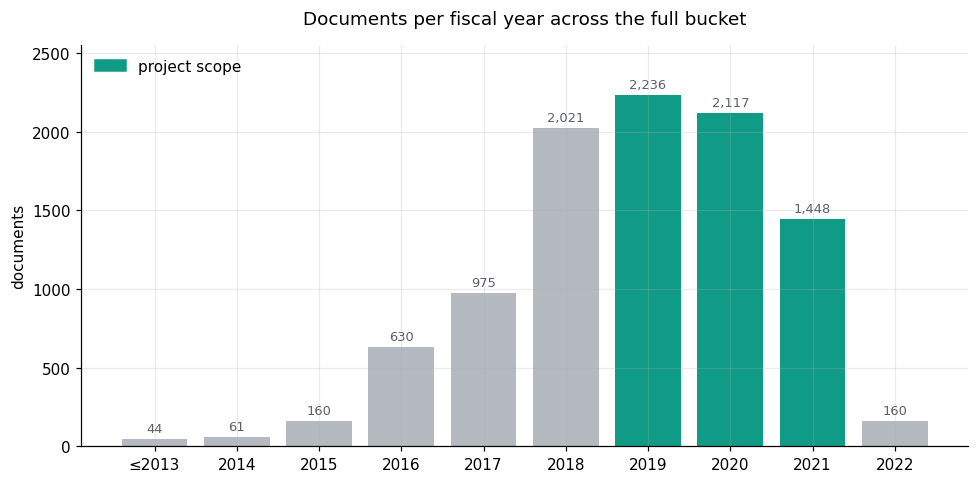

Files before 2014: 44 (earliest year 2003)
Share between 2018 and 2021: 79%


In [5]:
per_year = bucket["fiscal_year"].value_counts().sort_index()
early = per_year[per_year.index < 2014]
years = {"≤2013": int(early.sum())}
years.update({str(y): int(n) for y, n in per_year[per_year.index >= 2014].items()})
scope = {"2019", "2020", "2021"}

fig, ax = plt.subplots()
colors = [PALETTE["primary"] if y in scope else PALETTE["muted"] for y in years]
bars = ax.bar(list(years), years.values(), color=colors, edgecolor="none")

top = max(years.values())
for b, v in zip(bars, years.values()):
    ax.text(b.get_x() + b.get_width()/2, v + top * 0.02, f"{v:,}", ha="center", fontsize=8.5, color="#5b6168")

ax.set_title("Documents per fiscal year across the full bucket", fontsize=12, pad=14)
ax.set_ylabel("documents")
ax.set_ylim(0, top * 1.14)
ax.legend(handles=[plt.Rectangle((0,0),1,1, color=PALETTE["primary"])],
          labels=["project scope"], frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

print(f"Files before 2014: {early.sum()} (earliest year {early.index.min()})")
print(f"Share between 2018 and 2021: {per_year.loc[2018:2021].sum() / per_year.sum():.0%}")

Density sits between 2018 and 2021, which hold nearly 80% of the files. The bucket goes back
to 2003, but only 44 files fall before 2014. There is nothing from 2023 onward, and 2022
holds 160 files against 2,236 for 2019.

**Decision: the project scope is 2019, 2020 and 2021.** The brief hinted at recent
years, but the data does not support that. If a user asks about a year outside the
range, the bot says so rather than staying silent or inventing a figure.

## 3. How long is a 10-K

The brief says 100 to 300 pages. Let us measure it.

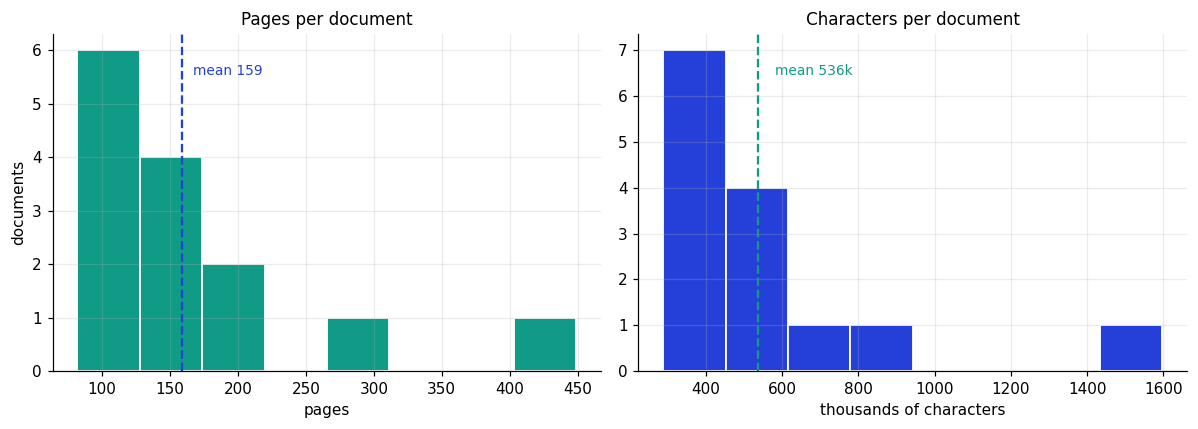

       pages      chars  chars_per_page
count   14.0       14.0            14.0
mean   159.0   536120.0          3387.0
std    101.0   344863.0           316.0
min     82.0   288722.0          2689.0
25%     96.0   311486.0          3150.0
50%    132.0   453292.0          3484.0
75%    169.0   548652.0          3574.0
max    449.0  1596424.0          3920.0

Median: 132 pages, 453,292 characters
Tesla: 2 of 14 documents, 32% of all characters


In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))

a1.hist(df["pages"], bins=8, color=PALETTE["primary"], edgecolor="white", linewidth=1.2)
a1.axvline(df["pages"].mean(), color=PALETTE["accent"], linestyle="--", linewidth=1.5)
a1.text(df["pages"].mean() + 8, a1.get_ylim()[1]*0.88,
        f"mean {df['pages'].mean():.0f}", color=PALETTE["accent"], fontsize=9)
a1.set_title("Pages per document", fontsize=11); a1.set_xlabel("pages"); a1.set_ylabel("documents")

a2.hist(df["chars"]/1000, bins=8, color=PALETTE["accent"], edgecolor="white", linewidth=1.2)
a2.axvline(df["chars"].mean()/1000, color=PALETTE["primary"], linestyle="--", linewidth=1.5)
a2.text(df["chars"].mean()/1000 + 45, a2.get_ylim()[1]*0.88,
        f"mean {df['chars'].mean()/1000:.0f}k", color=PALETTE["primary"], fontsize=9)
a2.set_title("Characters per document", fontsize=11); a2.set_xlabel("thousands of characters")

plt.tight_layout(); plt.show()

print(df[["pages", "chars", "chars_per_page"]].describe().round(0).to_string())

tesla_share = df.loc[df["ticker"] == "TSLA", "chars"].sum() / df["chars"].sum()
print(f"\nMedian: {df['pages'].median():.0f} pages, {df['chars'].median():,.0f} characters")
print(f"Tesla: {(df['ticker'] == 'TSLA').sum()} of {len(df)} documents, {tesla_share:.0%} of all characters")

The range is wider than the brief suggested: **82 to 449 pages**. Tesla 2020 is the
outlier at 449 pages and 1.6 million characters, roughly five times the shortest one.

**Tesla pulls the mean up.** Its two filings are 2 of 14 documents but hold about a third of
all characters. The median (132 pages, about 453k characters) describes a typical filing
better than the mean (159 pages, 536k). 449 pages is far beyond a normal 10-K; the most
likely explanation is exhibits appended after the last Item, to confirm in deliverable 2.

The practical consequence for deliverable 2: **process in batches, do not load everything
into memory at once.**

### File size is a bad proxy for content

A tempting shortcut is to estimate work from file size. It does not hold here.

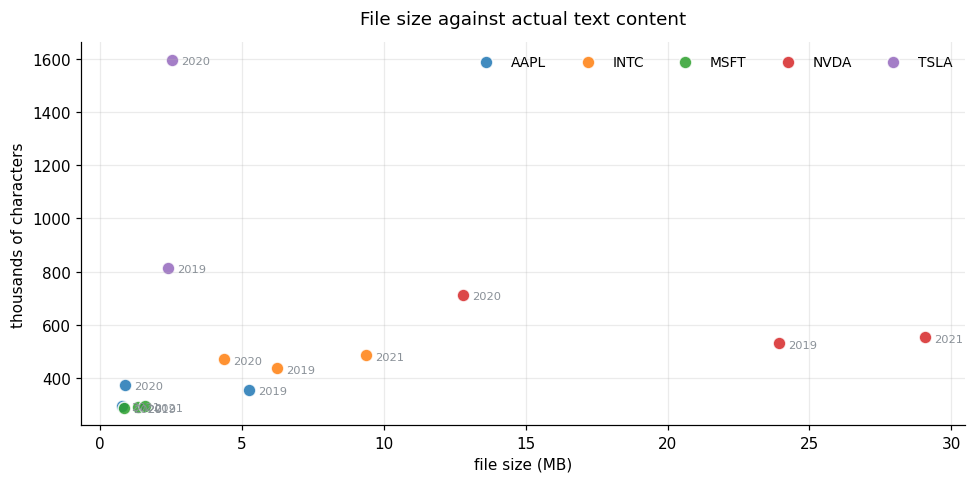

Correlation between size and characters: 0.06


In [7]:
fig, ax = plt.subplots()
for t, g in df.groupby("ticker"):
    ax.scatter(g["size_mb"], g["chars"]/1000, s=70, label=t, alpha=0.85, edgecolor="white", linewidth=1)
    for _, r in g.iterrows():
        ax.annotate(str(r["fiscal_year"]), (r["size_mb"], r["chars"]/1000),
                    textcoords="offset points", xytext=(6, -3), fontsize=7.5, color="#8a9198")

ax.set_xlabel("file size (MB)"); ax.set_ylabel("thousands of characters")
ax.set_title("File size against actual text content", fontsize=12, pad=12)
ax.legend(frameon=False, ncol=5, fontsize=9)
plt.tight_layout(); plt.show()

corr = df["size_mb"].corr(df["chars"])
print(f"Correlation between size and characters: {corr:.2f}")

NVIDIA 2021 weighs **29 MB** and Apple 2021 weighs **0.8 MB**, a 36x difference.
Yet Apple holds 296k characters and NVIDIA 554k, less than 2x apart.

The gap is images and layout, not content. NVIDIA publishes a designed report,
Apple publishes plain text.

**Use characters, not megabytes, to size the work.**

## 4. Is the text extractable

A scanned PDF is a photo of text. PyMuPDF returns nothing from it, and the document
would need OCR to be usable. OCR is slow, uneven, and misreads digits, which is
unacceptable for financial figures.

So this is a real risk worth measuring rather than assuming.

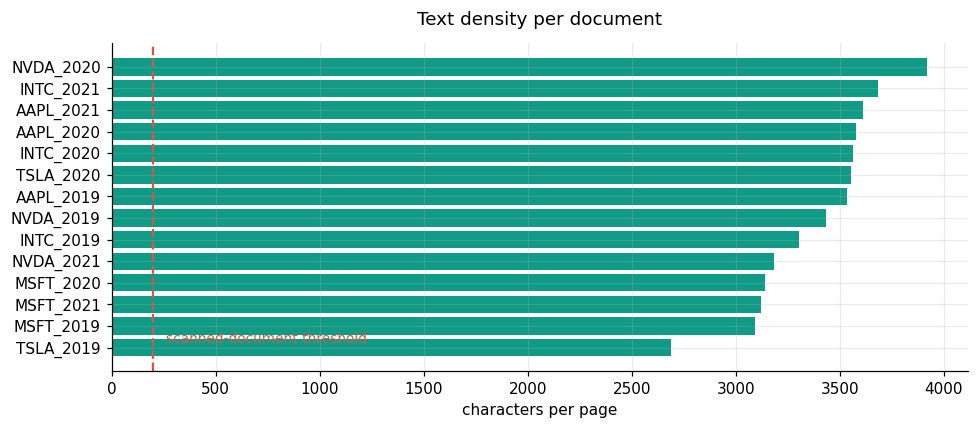

Documents with more than 20% blank pages: 0
Lowest text density: 2,689 characters per page


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
d = df.sort_values("chars_per_page")
bars = ax.barh(d["file"], d["chars_per_page"], color=PALETTE["primary"], edgecolor="none")
ax.axvline(200, color=PALETTE["warn"], linestyle="--", linewidth=1.5)
ax.text(260, 0.2, "scanned-document threshold", color=PALETTE["warn"], fontsize=9)
ax.set_xlabel("characters per page")
ax.set_title("Text density per document", fontsize=12, pad=12)
plt.tight_layout(); plt.show()

print(f"Documents with more than 20% blank pages: {(df['pct_blank'] > 20).sum()}")
print(f"Lowest text density: {df['chars_per_page'].min():,} characters per page")

**All fourteen documents have extractable text. No scanned PDFs.**

Even the least dense document sits far above the threshold. This closes one of the
project's open risks: **no OCR needed.**

## 5. The Item structure

This is what the whole chunking strategy rests on.

A 10-K is a regulated form with fixed numbered sections. If they are present, we can
cut the text by section and every chunk carries the label of the section it came from.
A chunk that knows it belongs to *Item 1A, Risk Factors* is worth far more to a
retrieval system than a loose thousand characters.

Seven sections matter for our use case:

| Item | Content |
| --- | --- |
| Item 1 | The business |
| Item 1A | Risk factors |
| Item 3 | Legal proceedings |
| Item 5 | Market for the stock |
| Item 7 | Management discussion and analysis |
| Item 7A | Market risk |
| Item 8 | Financial statements |

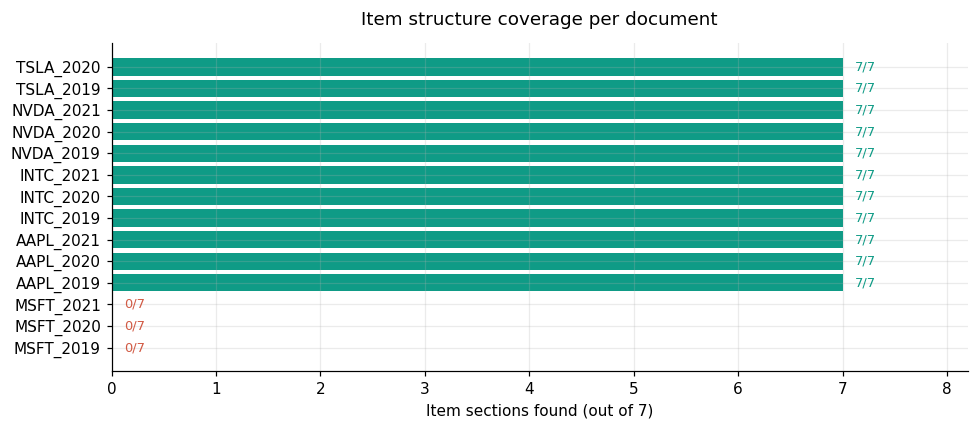

11 of 14 documents carry all seven Item sections (79%)

Without Item structure:
     file ticker  fiscal_year
MSFT_2019   MSFT         2019
MSFT_2020   MSFT         2020
MSFT_2021   MSFT         2021


In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
d = df.sort_values(["items_found", "file"])
colors = [PALETTE["primary"] if v == 7 else PALETTE["warn"] for v in d["items_found"]]
bars = ax.barh(d["file"], d["items_found"], color=colors, edgecolor="none")
for b, v in zip(bars, d["items_found"]):
    ax.text(v + 0.12, b.get_y() + b.get_height()/2, f"{v}/7",
            va="center", fontsize=8.5,
            color=PALETTE["primary"] if v == 7 else PALETTE["warn"])
ax.set_xlim(0, 8.2); ax.set_xlabel("Item sections found (out of 7)")
ax.set_title("Item structure coverage per document", fontsize=12, pad=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout(); plt.show()

complete = (df["items_found"] == 7).sum()
print(f"{complete} of {len(df)} documents carry all seven Item sections "
      f"({complete/len(df)*100:.0f}%)")
print("\nWithout Item structure:")
print(df.loc[df["items_found"] == 0, ["file", "ticker", "fiscal_year"]].to_string(index=False))

### Finding 3 · There are two document types, not one

In [10]:
import pymupdf

for name in ["AAPL_2021", "MSFT_2021"]:
    doc = pymupdf.open(DATA / "raw" / f"{name}.pdf")
    head = doc[0].get_text().strip()
    doc.close()
    print("=" * 66)
    print(name)
    print("=" * 66)
    print(head[:340] if head else "(empty first page)")
    print()

AAPL_2021
UNITED STATES
SECURITIES AND EXCHANGE COMMISSION
Washington, D.C. 20549
FORM 10-K
(Mark One)
☒    ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934
For the fiscal year ended September 25, 2021
or
☐    TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934
For the transit

MSFT_2021
1 
  
 
 
 
 
 
 
 
 
Annual Report 2021



Apple opens with `UNITED STATES SECURITIES AND EXCHANGE COMMISSION · FORM 10-K`.
Microsoft opens with `Annual Report 2021` and nothing else.

**These are two different documents.** The brief did say *"Annual reports **and** 10-K
statements"*, and it turns out that was literal:

- The **10-K** is the regulatory form filed with the SEC, with numbered Item sections
- The **Annual Report** is the designed shareholder version, without that structure

The three Microsoft files are Annual Reports. They are not mislabelled, they are simply
a different kind of document.

**Consequence:** chunking by section works on 79% of the sample. The remaining 21%
needs a different strategy, most likely fixed-size chunks with overlap, leaving the
`section` field empty.

This was not predicted by anyone. It surfaced from measuring, which is precisely
what exploring before building is for.

### Item headings are written in more than one way

If the section pattern is going to drive the chunking, it has to survive the way these
documents are actually written.

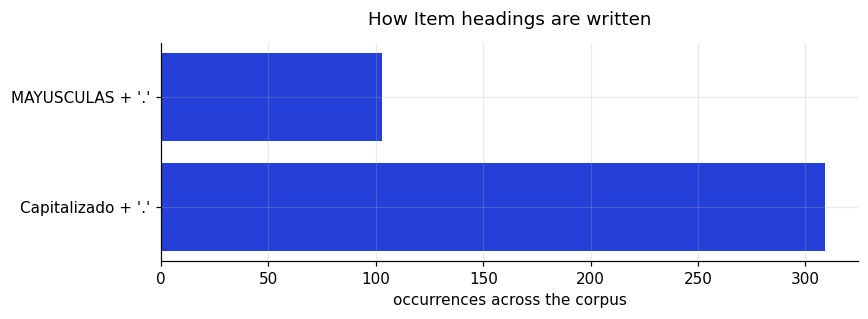

  Capitalizado + '.'          309  (75%)
  MAYUSCULAS + '.'            103  (25%)


In [11]:
from collections import Counter

formats = Counter()
for doc in detail:
    formats.update(doc.get("formatos_item", {}))

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(list(formats.keys()), list(formats.values()), color=PALETTE["accent"], edgecolor="none")
ax.set_xlabel("occurrences across the corpus")
ax.set_title("How Item headings are written", fontsize=12, pad=12)
plt.tight_layout(); plt.show()

total = sum(formats.values())
for k, v in formats.most_common():
    print(f"  {k:<26} {v:>4}  ({v/total*100:.0f}%)")

Two distinct forms appear: **capitalised** (`Item 1A.`) and **uppercase** (`ITEM 1A.`).

A strict pattern matching only one of them would miss roughly a quarter of all sections.
The pattern has to be flexible on both case and separator:

```python
re.compile(rf"\bitem\s+{num}\b[\.\:\s\-—]", re.IGNORECASE)
```

The trailing character class accepts a period, colon, space, hyphen or em dash. The
second `\b` is what keeps a search for `Item 1` from matching `Item 1A`.

### A trap worth knowing about

Each Item typically appears **twice**: once in the table of contents, once as the actual
section heading.

In [12]:
rows = []
for doc in detail:
    if doc.get("items_encontrados", 0) == 0:
        continue
    for item, n in doc["items"].items():
        rows.append({"document": doc["archivo"], "item": item, "occurrences": n})

occ = pd.DataFrame(rows).pivot(index="document", columns="item", values="occurrences")
occ = occ[["Item 1", "Item 1A", "Item 3", "Item 5", "Item 7", "Item 7A", "Item 8"]]
print("Times each Item appears per document\n")
print(occ.fillna(0).astype(int).to_string())

Times each Item appears per document

item       Item 1  Item 1A  Item 3  Item 5  Item 7  Item 7A  Item 8
document                                                           
AAPL_2019       2        6       3       2       4        2      14
AAPL_2020       2        6       3       2       4        2      15
AAPL_2021       2        6       3       2       4        2       8
INTC_2019       1        1       1       1       1        1       1
INTC_2020       1        1       1       1       1        1       1
INTC_2021       1        1       1       1       1        1       1
NVDA_2019       2        3       2       2       2        3       2
NVDA_2020       2        3       2       2       3        2       2
NVDA_2021       2        5       2       2       3        2       2
TSLA_2019       2        2       2       2       3        2       3
TSLA_2020       2        2       2       2       3        2       3


Taking the *first* occurrence lands on the table of contents, not the content.

For deliverable 2 the rule is: **take the last occurrence of each Item**, or discard
matches that fall within the opening pages.

## 6. How many chunks will this produce

This number decides whether the index is comfortable or a problem. Assuming one
thousand characters per chunk.

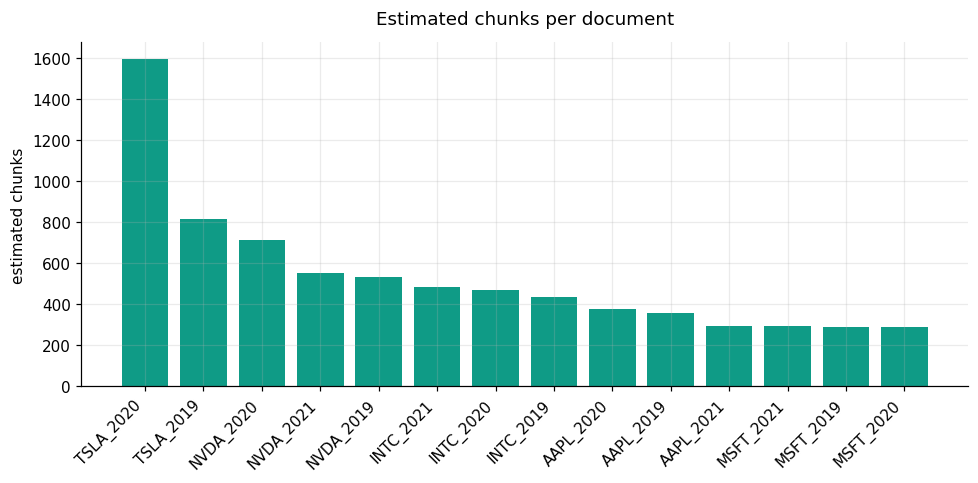

Sample:      14 documents  ->  7,505 chunks
Average:     536 chunks per document
Median:      453 chunks per document
Projection:  75 documents  ->  33,975 chunks (median) to 40,205 (mean)


In [13]:
df["chunks_est"] = (df["chars"] / 1000).round().astype(int)

fig, ax = plt.subplots()
d = df.sort_values("chunks_est", ascending=False)
ax.bar(d["file"], d["chunks_est"], color=PALETTE["primary"], edgecolor="none")
ax.set_ylabel("estimated chunks"); ax.set_title("Estimated chunks per document", fontsize=12, pad=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

sample_chunks = df["chunks_est"].sum()
per_doc = sample_chunks / len(df)
corpus_docs = 25 * 3
print(f"Sample:      {len(df)} documents  ->  {sample_chunks:,} chunks")
print(f"Average:     {per_doc:.0f} chunks per document")
median_doc = df["chunks_est"].median()
print(f"Median:      {median_doc:.0f} chunks per document")
print(f"Projection:  {corpus_docs} documents  ->  {median_doc * corpus_docs:,.0f} chunks (median) "
      f"to {per_doc * corpus_docs:,.0f} (mean)")

**Between 34,000 and 40,000 chunks** for the final corpus of 25 companies over three years.
The median gives the lower figure and is the more honest one, since Tesla inflates the mean.

Either way it is a comfortable volume. Elasticsearch handles it without effort and a local
embedding model processes it in a reasonable time. **Volume is not a risk for this project.**

### One constraint on chunk size

The embedding model has a token limit. BGE handles around **512 tokens**, roughly
2,000 characters in English. Anything longer gets silently truncated: no error,
no warning, just missing text.

An `Item 1A` section can easily run fifty thousand characters.

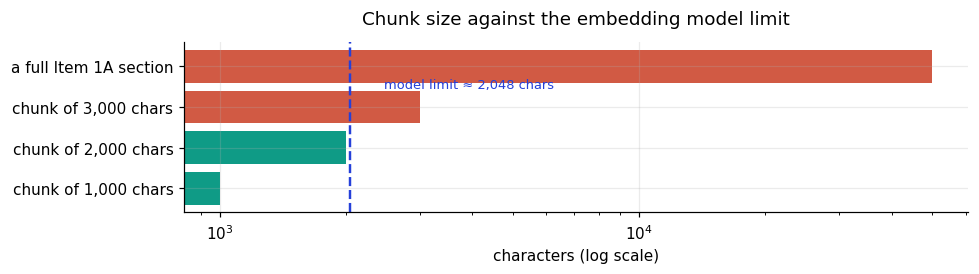

In [14]:
CHARS_PER_TOKEN = 4       # rough for English
MODEL_LIMIT = 512

fig, ax = plt.subplots(figsize=(9, 2.6))
sizes = {"chunk of 1,000 chars": 1000, "chunk of 2,000 chars": 2000,
         "chunk of 3,000 chars": 3000, "a full Item 1A section": 50000}
lim = MODEL_LIMIT * CHARS_PER_TOKEN
colors = [PALETTE["primary"] if v <= lim else PALETTE["warn"] for v in sizes.values()]
ax.barh(list(sizes.keys()), list(sizes.values()), color=colors, edgecolor="none")
ax.axvline(lim, color=PALETTE["accent"], linestyle="--", linewidth=1.6)
ax.text(lim*1.2, 2.55, f"model limit ≈ {lim:,} chars",
        color=PALETTE["accent"], fontsize=8.5, va="center")
ax.set_xscale("log"); ax.set_xlabel("characters (log scale)")
ax.set_title("Chunk size against the embedding model limit", fontsize=12, pad=12)
plt.tight_layout(); plt.show()

**Chunking by section does not mean one chunk per section.**

Sections get split internally, and every resulting chunk inherits the section name.
The `section` field is metadata, not the size criterion.

At one thousand characters per chunk we sit safely inside the limit.

## 7. Is the filename metadata trustworthy

The whole pipeline depends on the path being truthful. A mislabelled document would
make the bot cite the wrong company, which is the worst failure this product can have.

The check looks for the ticker, the year and the document type inside the opening
pages of each file.

In [15]:
rows = []
for doc in detail:
    if "coherencia" not in doc:
        continue
    ch = doc["coherencia"]
    rows.append({"document": doc["archivo"],
                 "ticker in text": ch["ticker_en_texto"],
                 "year in text": ch["anio_en_texto"],
                 "says 10-K or Annual Report": ch["dice_10k"]})

coh = pd.DataFrame(rows).set_index("document")
print(coh.to_string())
print(f"\nFully confirmed: {coh.all(axis=1).sum()} of {len(coh)}")

           ticker in text  year in text  says 10-K or Annual Report
document                                                           
AAPL_2019            True          True                        True
AAPL_2020            True          True                        True
AAPL_2021            True          True                        True
INTC_2019           False          True                        True
INTC_2020            True          True                        True
INTC_2021            True          True                        True
MSFT_2019           False          True                       False
MSFT_2020           False          True                       False
MSFT_2021           False          True                        True
NVDA_2019           False          True                        True
NVDA_2020           False          True                        True
NVDA_2021           False          True                        True
TSLA_2019            True          True         

Some documents do not print their own ticker in the opening pages, which is normal:
the SEC cover sheet carries the commission file number and the legal name, not always
the trading symbol.

The document-type check looks for either `Form 10-K` or `Annual Report` on the opening
pages. Microsoft 2019 and 2020 print neither there; Microsoft 2021 passes because it says
*Annual Report*. All three are Annual Reports, consistent with finding 3.

**No document in the sample is mislabelled.** At bucket level the picture has one caveat.

### Finding 4 · The ticker is a reliable key, the company folder is not

Some tickers appear twice for the same fiscal year, under different company folders.

In [16]:
dup = bucket[bucket.duplicated(["ticker", "fiscal_year"], keep=False)]
by_ticker = (dup.groupby("ticker")
                .agg(years=("fiscal_year", lambda s: f"{s.min()} to {s.max()}"),
                     folders=("company", lambda s: ", ".join(sorted(s.unique())))))

print(f"{dup['ticker'].nunique()} tickers, {len(dup) // 2} duplicated ticker and year pairs, "
      f"{len(dup)} files ({len(dup) / len(bucket):.1%} of the bucket)\n")
by_ticker

11 tickers, 29 duplicated ticker and year pairs, 58 files (0.6% of the bucket)



,years,folders
ticker,,
CCNE,2017 to 2020,"city-national-bank, cnb-financial-corporation"
CHEF,2016 to 2020,"chefs-wharehouse, the-chefs-warehouse"
CTIC,2018 to 2021,"cti-biopharma, cti-biopharma-corp"
EXFO,2018 to 2018,exfo-inc
HCKT,2018 to 2019,"hackett-group-inc, the-hackett-group-inc"
INAP,2018 to 2018,"internap-corporation, internap-network-services"
INTU,2019 to 2019,intuit-inc
PANL,2018 to 2019,"pangaea-logistics-solutions-ltd, universal-display-corporation"
TTEC,2018 to 2021,"teletech-holdings-inc, ttec-holdings-inc"


Most are the same company saved twice:

- **Typos in the folder name:** `chefs-wharehouse` next to `the-chefs-warehouse`
- **Company renames:** TeleTech became TTEC
- **The same file uploaded with and without the hash suffix:** EXFO, INTU, WLTW

Two are worth a closer look. PANL groups Pangaea Logistics with Universal Display, which are
different companies, so one of them carries the wrong ticker. CCNE shows very different file
sizes across folders, so the two may not be the same document.

**Rule for the pipeline: identify documents by `ticker` + `fiscal_year`, never by company
folder, and keep one file per pair.** This is what the `doc_id` in the data contract already
does. None of these tickers is a candidate for the final corpus.

## 8. Coverage

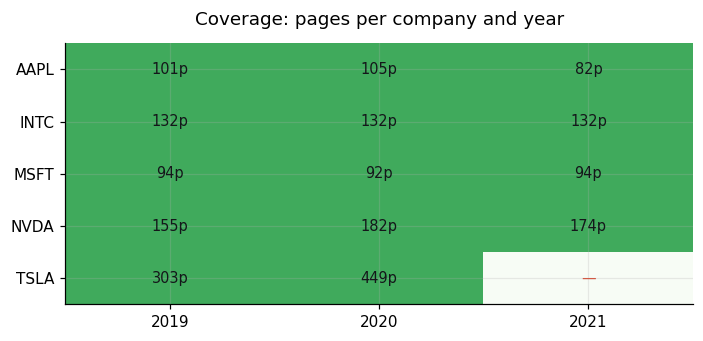

Distinct content hashes: 14 of 14 documents


In [17]:
pivot = df.pivot_table(index="ticker", columns="fiscal_year", values="pages", aggfunc="first")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.imshow(pivot.notna().values, cmap="Greens", vmin=0, vmax=1.6, aspect="auto")
ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_yticks(range(len(pivot.index)), pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.iloc[i, j]
        ax.text(j, i, f"{int(v)}p" if pd.notna(v) else "—",
                ha="center", va="center", fontsize=9.5,
                color="#14161a" if pd.notna(v) else PALETTE["warn"])
ax.set_title("Coverage: pages per company and year", fontsize=12, pad=12)
plt.tight_layout(); plt.show()

print(f"Distinct content hashes: {df['hash'].nunique()} of {len(df)} documents")

Tesla has no 2021 filing in the dataset. **We kept it that way on purpose:** when a
user asks about that year the bot will say it does not have it and show the available
range. It turns a dataset gap into a live demonstration of the product rule.

No duplicates: all fourteen documents are distinct.

### Finding 5 · Which recognisable companies are available

The final corpus needs 25 companies that people know and that cover 2019 to 2021. The
check has to run against the bucket, not against memory: tickers change over time.

In [18]:
candidates = ["AAPL", "NVDA", "AMD", "AMZN", "INTC", "FB", "META", "MSFT", "TSLA", "GOOG", "GOOGL", "NFLX"]
target = {2019, 2020, 2021}

rows = []
for t in candidates:
    ys = set(bucket.loc[bucket["ticker"] == t, "fiscal_year"])
    rows.append({"ticker": t,
                 "years in bucket": f"{min(ys)} to {max(ys)}" if ys else "not in bucket",
                 "2019 to 2021": "complete" if target <= ys else ("missing " + ", ".join(map(str, sorted(target - ys))) if ys else "none")})
pd.DataFrame(rows).set_index("ticker")

,years in bucket,2019 to 2021
ticker,,
AAPL,2019 to 2022,complete
NVDA,2019 to 2022,complete
AMD,2019 to 2022,complete
AMZN,2017 to 2021,complete
INTC,2018 to 2021,complete
FB,2018 to 2021,complete
META,not in bucket,none
MSFT,2019 to 2021,complete
TSLA,2016 to 2020,missing 2021


**Meta is in the bucket as `FB`**, its ticker until 2022. Searching for `META` finds nothing.
Alphabet and Netflix are absent. Microsoft covers the three years but as Annual Reports, and
Tesla is missing 2021.

Choosing the final 25 means checking three things per company: coverage of 2019 to 2021,
document type, and that the ticker is not in the duplicate list above.

## 9. Tables

Financial statements come as tables. A table rendered in a PDF is not structured data,
it is text drawn at coordinates. Extracting it flattens the layout and the numbers can
lose their column.

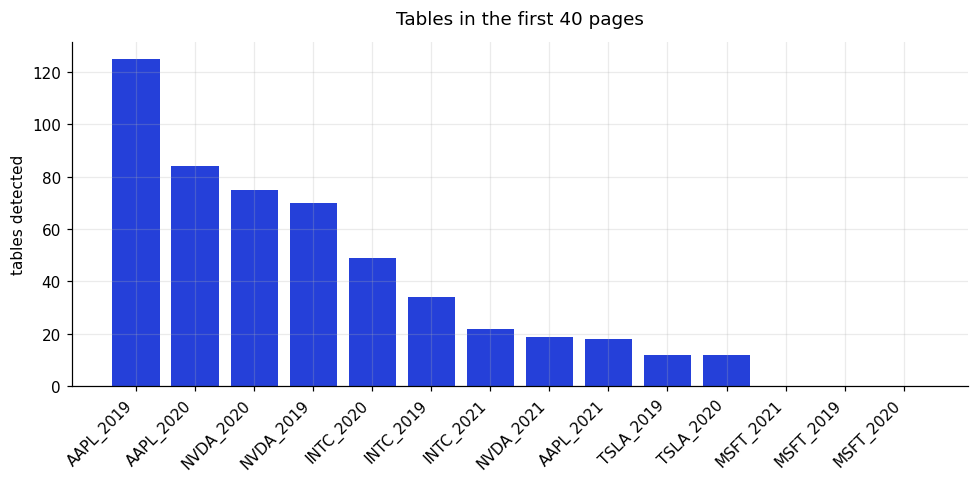

Total detected: 520
Average per document: 37


In [19]:
fig, ax = plt.subplots()
d = df.sort_values("tables_40p", ascending=False)
ax.bar(d["file"], d["tables_40p"], color=PALETTE["accent"], edgecolor="none")
ax.set_ylabel("tables detected"); ax.set_title("Tables in the first 40 pages", fontsize=12, pad=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

print(f"Total detected: {df['tables_40p'].sum()}")
print(f"Average per document: {df['tables_40p'].mean():.0f}")

**520 tables across just the first 40 pages of each document**, around 37 per document.
This is a large share of the content, not an edge case.

A row that reads

```
Revenue        365,817        274,515
```

can come out as `Revenue 365,817 274,515`, with no indication of which figure belongs
to which year. If that text reaches the language model, it has to guess. Guessing
financial figures is exactly what this product promises not to do.

**This is the open question for deliverable 2**, and it decides whether questions about
specific figures stay in scope.

## 10. Conclusions

### Risks closed by this analysis

| Risk | Status |
| --- | --- |
| Scanned documents needing OCR | **Closed.** All documents have extractable text |
| Metadata extraction could cost two days | **Closed.** 9,852 of 9,855 files parse from the filename |
| Corpus volume could overwhelm the index | **Closed.** Between 34,000 and 40,000 chunks is comfortable |
| Mixed or unexpected languages | **Closed.** All English |
| Duplicate documents in the sample | **Closed.** All distinct |
| Duplicate documents in the bucket | **Closed with a rule.** Key is `ticker` + `fiscal_year` |

### Risks that surfaced

| Risk | Impact |
| --- | --- |
| Two document types, 21% without Item sections | Chunking needs a fallback strategy |
| 520 tables where figures may lose their column | Decides whether figure questions stay in scope |
| Embedding model truncates past ~2,000 characters | Sections must be split internally |
| Some 10-Ks may carry appended exhibits | Filler chunks competing in search |

### Decisions taken from the data

1. **Scope is 2019 to 2021.** The dataset does not support recent years
2. **Work with 10-K filings first.** Annual Reports pending a scope decision
3. **Tesla stays with two years.** The gap becomes a demonstration of the product rule
4. **Chunk at one thousand characters.** Comfortably inside the model limit
5. **Identify documents by ticker and fiscal year.** Company folders have typos and duplicates

### What comes next

Deliverable 2 picks up from `data/raw/`: extract, clean, split and produce the chunks
in the agreed contract shape.

The `inventario.csv` carries the metadata already resolved. The `caracterizacion.json`
carries the section detail per document. **Neither requires opening a PDF again.**
Choosing the final 25 companies starts from `bucket_inventory.csv`.

---

*Reproducible with the three scripts in `eda/`. The download script is deterministic:
it fetches the same files regardless of who runs it, so these numbers can be verified.*